# 第7回　クラスタリング

- 階層化クラスタリング（省略）
- scikit-learnライブラリ
- k-means

### scikit-learn

scikitlearn ライブラリの KMeans クラスを使ったk-means法によるクラスタリングについて説明

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# matplotlibでの日本語表示用
from matplotlib import font_manager
fp = font_manager.FontProperties(fname="ipag.ttf")

In [2]:
from sklearn.datasets import load_iris

### iris

iris データセットにはアヤメの花を4つの特徴量（'sepal length (cm)', 'sepal width (cm)', 'petal length
(cm)', 'petal width (cm)'）で表した150個の特徴量ベクトルが含まれています(iris['data'])。

また、各花には3種類（0:'setosa', 1:'versicolor', 2:'virginica'）のいずれかがラベルとして付与されています（ iris['target'] )

In [10]:
iris = load_iris()
print(len(iris['data']))
print(iris['feature_names']) # 特徴量名
print(iris['data'][0:5]) # 先頭5行

print(iris['target_names']) # ラベル名
print(iris['target'][0:5], iris['target'][50:55],
        iris['target'][100:105]) # ラベル

150
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0] [1 1 1 1 1] [2 2 2 2 2]


In [11]:
iris_df = pd.DataFrame(iris['data'], columns=iris['feature_names'])
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 散布図で可視化

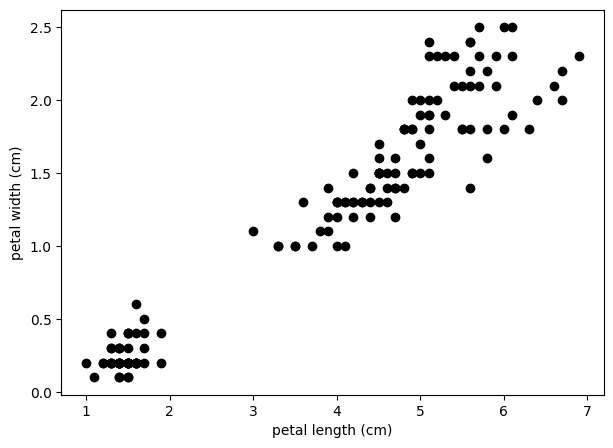

In [16]:
# （'petal length (cm)', 'petal width (cm)'）を抽出
x_iris = iris['data'][:, 2:4]

plt.figure(figsize=(7,5))
plt.xlabel(iris["feature_names"][2])
plt.ylabel(iris["feature_names"][3])
plt.scatter(x_iris[:, 0], x_iris[:, 1], c='black');

アヤメの種類（0:'setosa', 1:'versicolor', 2:'virginica'）ごとに色を変えて同様にデータを可視化してみると、種類ごとにグループになっており、アヤメの種類ごとに似た特徴量を持っていることがわかり

In [29]:
labels = iris['target']
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

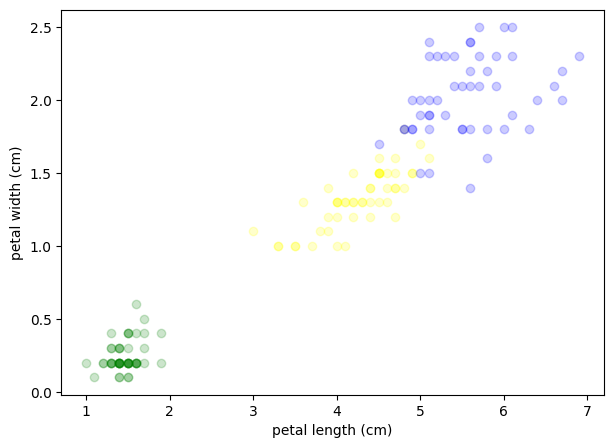

In [ ]:
plt.figure(figsize=(7,5))
plt.xlabel(iris["feature_names"][2])
plt.ylabel(iris["feature_names"][3])
plt.scatter(x_iris[labels==0,0], x_iris[labels==0,1], c='green', alpha=0.2)
plt.scatter(x_iris[labels==1,0], x_iris[labels==1,1], c='yellow', alpha=0.2)
plt.scatter(x_iris[labels==2,0], x_iris[labels==2,1], c='blue', alpha=0.2);

### scikit-learnでの機械学習手順
この色ごとにクラスタリングしていくよ〜〜〜〜

- 使用するモデルのクラスの選択
- モデルのハイパーパラメータの選択とインスタンス化
- データの準備
  - 教師なし学習では、特徴量データを準備

- モデルをデータに適合（ fit() メソッド）
- モデルの評価
  - 教師なし学習では、 transform() または predict() メソッドを用いて特徴量データのクラスタリングや次元削減などを行う

In [19]:
from sklearn.cluster import KMeans

In [ ]:
model = KMeans(n_clusters=3)


# fit() メソッドによりモデルを入力データ x_iris に適合
model.fit(x_iris)

# predict() メソッドを用いて各データが所属するクラスタ（0,1,2で表現）の情報をリストとして取得
clusters = model.predict(x_iris)
clusters

# 計算により求まった中心点
centers = model.cluster_centers_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

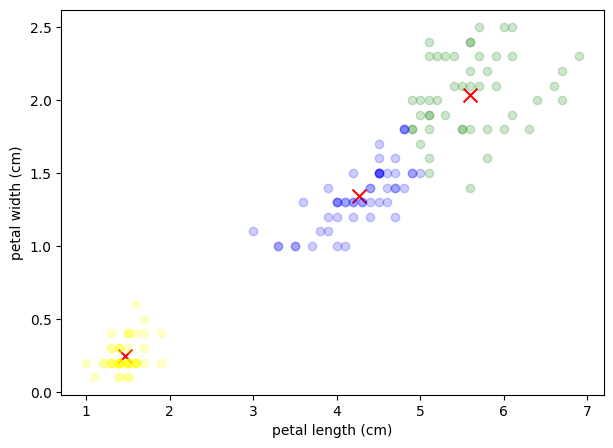

In [34]:
plt.figure(figsize=(7,5))
plt.xlabel(iris["feature_names"][2])
plt.ylabel(iris["feature_names"][3])
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100)
plt.scatter(x_iris[clusters==0,0], x_iris[clusters==0,1], c='green', alpha=0.2)
plt.scatter(x_iris[clusters==1,0], x_iris[clusters==1,1], c='yellow', alpha=0.2)
plt.scatter(x_iris[clusters==2,0], x_iris[clusters==2,1], c='blue', alpha=0.2);

In [32]:
print(model.inertia_) # コスト関数の値

31.371358974358973


### Q2 K−means